In [27]:
import pandas as pd
import seaborn as sns

In [28]:
def load_json_data(json_path):
    with open(json_path, "r") as file:
        return json.load(file)

def flatten_data(results_data, experiment_type=None):
    records_list = []
    for dataset_name, model_dict in results_data.items():
        for model_name, records in model_dict.items():
            for r in records:
                method = r.get("method", "unknown")
                records_list.append({
                    "dataset": dataset_name,
                    "model_name": model_name,
                    "distance_name": r["distance_name"],
                    "distance_type": r.get("distance_type", "vector"),
                    "pca_applied": r.get("pca_applied", False),
                    "method": method,
                    "drift_strength": r["drift_strength"],
                    "final_similarity": r["final_similarity"],
                    "avg_overhead": r.get("avg_overhead", float('nan')),
                    "time_taken": r.get("time_taken", float('nan')),
                    "avg_memory_mb": r.get("avg_memory_mb", float('nan')),
                    "peak_memory_mb": r.get("peak_memory_mb", r.get("avg_memory_mb", float('nan'))),
                    "experiment_type": experiment_type  # Add experiment type
                })
    return pd.DataFrame(records_list)

In [29]:
# Load newly uploaded JSONs with distinct names
vector_data = load_json_data("/Users/jasper.bruin/Documents/driftwatch/driftwatch/data/vector_experiment/2025-04-15_19-16-28/results.json")
distribution_data = load_json_data("/Users/jasper.bruin/Documents/driftwatch/driftwatch/data/distribution_experiment/2025-04-11_07-51-52/results.json")

# Flatten both with appropriate experiment_type
df_vector = flatten_data(vector_data, experiment_type="vector")
df_distribution = flatten_data(distribution_data, experiment_type="distribution")

# Combine into a single DataFrame
combined_df = pd.concat([df_vector, df_distribution], ignore_index=True)

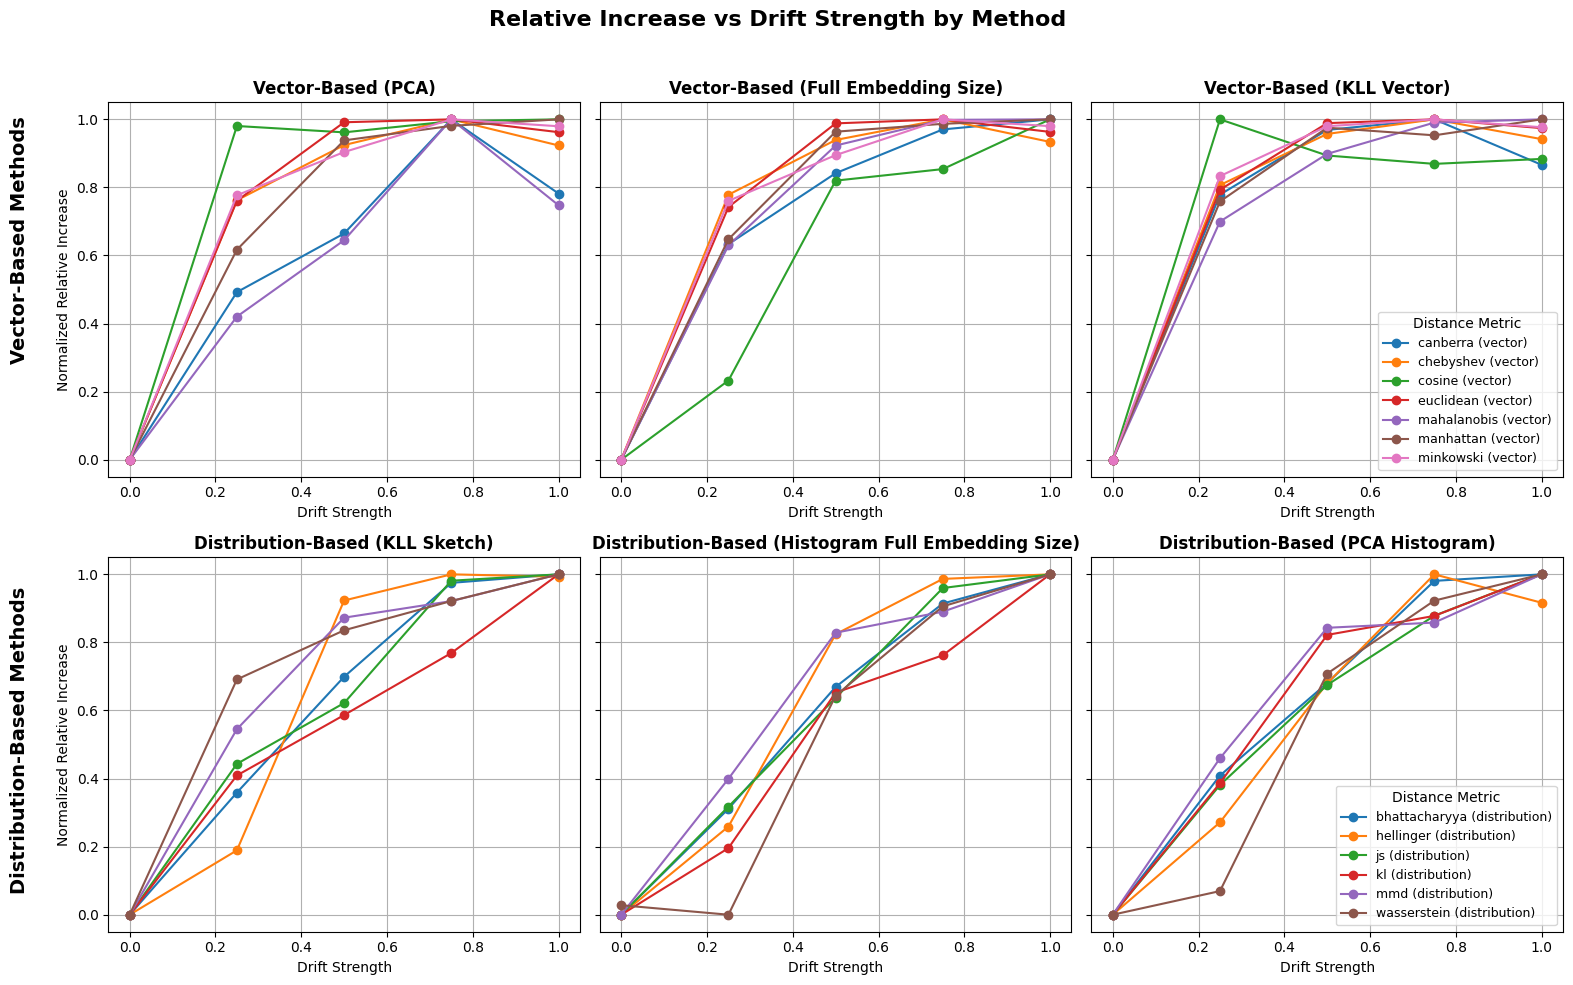

Plot saved to: /Users/jasper.bruin/Documents/driftwatch/driftwatch/data/combined_experiment/plot_relative_log_increase_6subplots.png


In [30]:
# Re-import everything necessary after kernel context loss
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load JSON data
def load_json_data(json_path):
    with open(json_path, "r") as file:
        return json.load(file)

# Flatten the structured JSON into a DataFrame
def flatten_data(results_data, experiment_type=None):
    records_list = []
    for dataset_name, model_dict in results_data.items():
        for model_name, records in model_dict.items():
            for r in records:
                method = r.get("method", "unknown")
                records_list.append({
                    "dataset": dataset_name,
                    "model_name": model_name,
                    "distance_name": r["distance_name"],
                    "distance_type": r.get("distance_type", "vector"),
                    "pca_applied": r.get("pca_applied", False),
                    "method": method,
                    "drift_strength": r["drift_strength"],
                    "final_similarity": r["final_similarity"],
                    "avg_overhead": r.get("avg_overhead", float('nan')),
                    "time_taken": r.get("time_taken", float('nan')),
                    "avg_memory_mb": r.get("avg_memory_mb", float('nan')),
                    "peak_memory_mb": r.get("peak_memory_mb", r.get("avg_memory_mb", float('nan'))),
                    "experiment_type": experiment_type
                })
    return pd.DataFrame(records_list)

# Plotting function
def plot_relative_log_increase(df, output_dir="/Users/jasper.bruin/Documents/driftwatch/driftwatch/data/combined_experiment"):
    plot_data = []

    for _, row in df.iterrows():
        if row["drift_strength"] >= 0:
            base_similarity_filter = [
                (df["drift_strength"] == 0),
                (df["distance_name"] == row["distance_name"]),
                (df["method"] == row["method"])
            ]
            if "experiment_type" in df.columns and row["experiment_type"] is not None:
                base_similarity_filter.append(df["experiment_type"] == row["experiment_type"])

            base_similarity = df.loc[np.logical_and.reduce(base_similarity_filter)]["final_similarity"].mean()

            if base_similarity and base_similarity > 0:
                rel_log = np.log(row["final_similarity"] / base_similarity)
                plot_data_row = {
                    "distance_name": row["distance_name"],
                    "drift_strength": row["drift_strength"],
                    "method": row["method"],
                    "distance_type": row["distance_type"],
                    "rel_log_increase": rel_log
                }
                if "experiment_type" in df.columns:
                    plot_data_row["experiment_type"] = row["experiment_type"]
                plot_data.append(plot_data_row)

    df_plot = pd.DataFrame(plot_data)

    df_normalized = []
    groupby_cols = ["distance_name", "method"]
    if "experiment_type" in df_plot.columns:
        groupby_cols.append("experiment_type")

    for group_key, group in df_plot.groupby(groupby_cols):
        df_avg = group.groupby("drift_strength")["rel_log_increase"].mean().reset_index()
        min_val = df_avg["rel_log_increase"].min()
        max_val = df_avg["rel_log_increase"].max()
        if max_val - min_val > 1e-12:
            df_avg["normalized"] = (df_avg["rel_log_increase"] - min_val) / (max_val - min_val)
        else:
            df_avg["normalized"] = 0.0

        if "experiment_type" in df_plot.columns:
            df_avg["distance_name"] = group_key[0]
            df_avg["method"] = group_key[1]
            df_avg["experiment_type"] = group_key[2]
        else:
            df_avg["distance_name"] = group_key[0]
            df_avg["method"] = group_key[1]

        df_avg["distance_type"] = group["distance_type"].iloc[0]
        df_normalized.append(df_avg)

    df_final = pd.concat(df_normalized, ignore_index=True)

    fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharey=True)

    method_positions = {
        (0, 0): "pca",
        (0, 1): "no_pca",
        (0, 2): "kll_vector",
        (1, 0): "kll_distribution",
        (1, 1): "histogram",
        (1, 2): "pca_histogram"
    }

    title_map = {
        "pca": "Vector-Based (PCA)",
        "no_pca": "Vector-Based (Full Embedding Size)",
        "kll_vector": "Vector-Based (KLL Vector)",
        "kll_distribution": "Distribution-Based (KLL Sketch)",
        "histogram": "Distribution-Based (Histogram Full Embedding Size)",
        "pca_histogram": "Distribution-Based (PCA Histogram)"
    }

    for i in range(2):
        for j in range(3):
            ax = axes[i, j]
            method = method_positions.get((i, j))

            if method:
                sub_df = df_final[df_final["method"] == method]

                if "experiment_type" in sub_df.columns:
                    for dist_name in sub_df["distance_name"].unique():
                        for exp_type in sub_df["experiment_type"].unique():
                            d = sub_df[(sub_df["distance_name"] == dist_name) &
                                       (sub_df["experiment_type"] == exp_type)]
                            if not d.empty:
                                label = f"{dist_name} ({exp_type})" if exp_type else dist_name
                                ax.plot(d["drift_strength"], d["normalized"], marker='o', label=label)
                else:
                    for dist_name in sub_df["distance_name"].unique():
                        d = sub_df[sub_df["distance_name"] == dist_name]
                        if not d.empty:
                            ax.plot(d["drift_strength"], d["normalized"], marker='o', label=dist_name)

                ax.set_title(title_map.get(method, f"Method: {method}"), fontsize=12, fontweight='bold')
                ax.set_xlabel("Drift Strength")
                ax.grid(True)

                if j == 0:
                    ax.set_ylabel("Normalized Relative Increase")

                if j == 2:
                    ax.legend(title="Distance Metric", fontsize=9)

    fig.text(0.02, 0.75, "Vector-Based Methods", fontsize=14, fontweight='bold', rotation=90, va='center')
    fig.text(0.02, 0.25, "Distribution-Based Methods", fontsize=14, fontweight='bold', rotation=90, va='center')

    fig.suptitle("Relative Increase vs Drift Strength by Method", fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0.04, 0, 1, 0.96])

    path_out = os.path.join(output_dir, "plot_relative_log_increase_6subplots.png")
    plt.savefig(path_out, dpi=300)
    plt.show()
    plt.close()
    return path_out

# Generate plot
output_plot_path = plot_relative_log_increase(combined_df)
print(f"Plot saved to: {output_plot_path}")


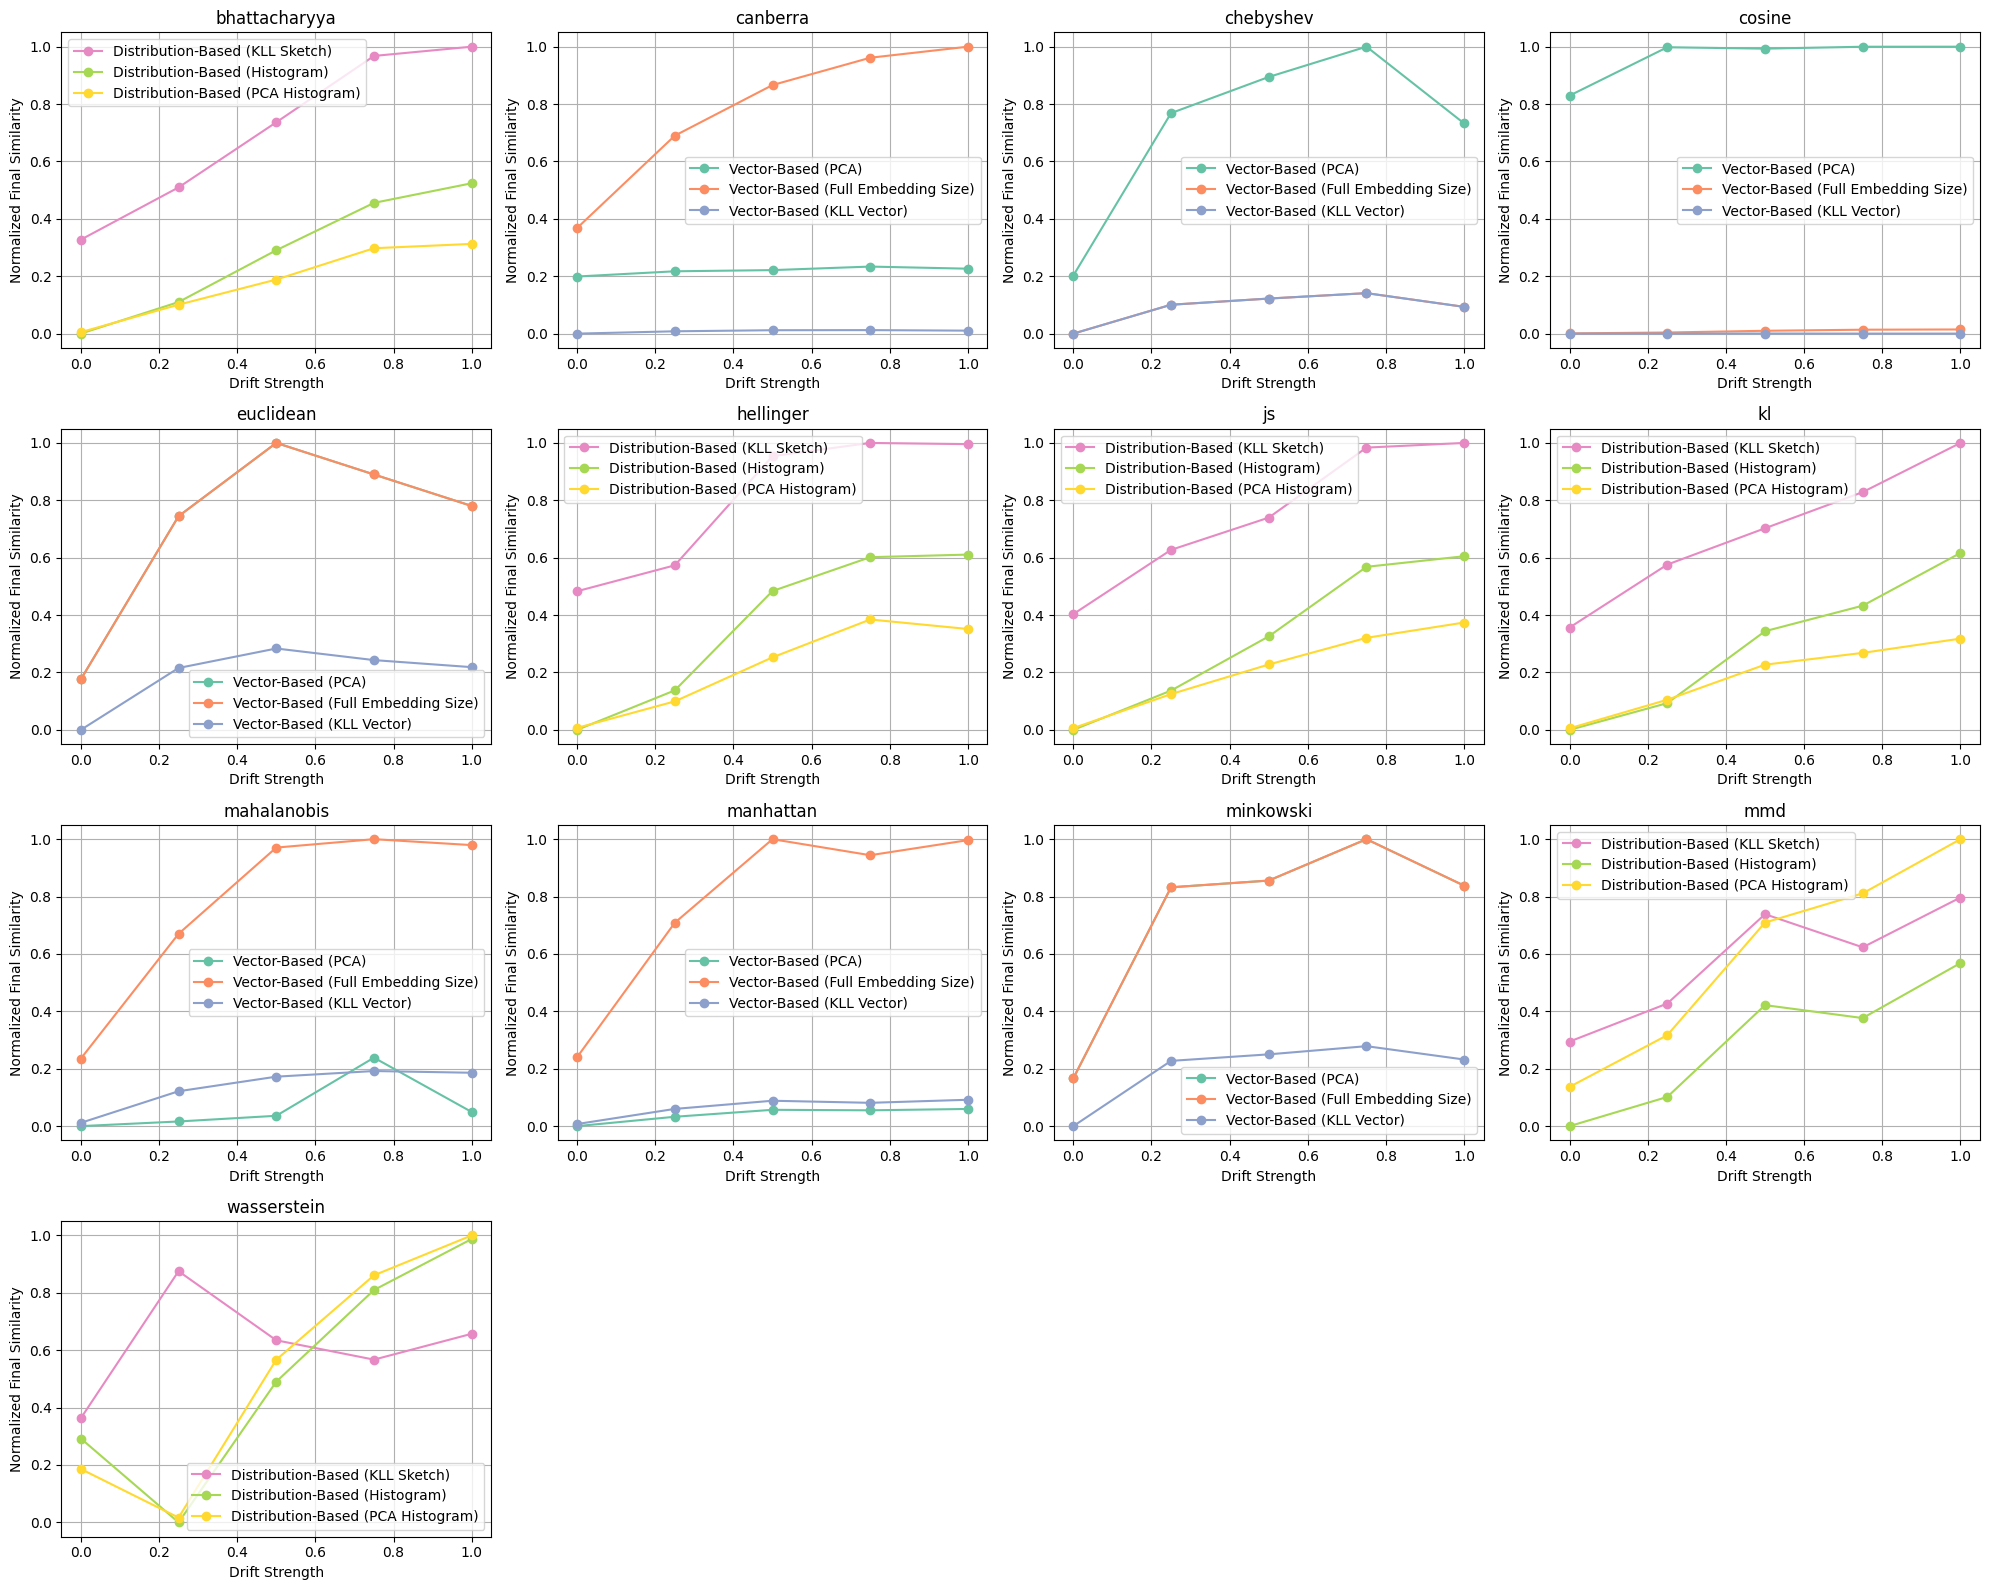

[Saved] /Users/jasper.bruin/Documents/driftwatch/driftwatch/data/combined_experiment/plot_final_similarity_all_methods_by_distance.png


In [31]:
def plot_final_similarity_separate(df, output_dir):
    """
    Creates 12 subplots (3x4 grid), one per distance_name.
    Each plot shows lines for both vector-based and distribution-based methods.
    """

    # Step 1: Compute mean final_similarity for each group
    df_sim = df.groupby(["distance_name", "drift_strength", "method", "experiment_type"], as_index=False)["final_similarity"].mean()

    # Step 2: Normalize final similarity within each distance metric
    df_sim["final_similarity_norm"] = 0.0
    for dist_name, group_data in df_sim.groupby("distance_name"):
        min_val = group_data["final_similarity"].min()
        max_val = group_data["final_similarity"].max()
        if max_val - min_val == 0:
            df_sim.loc[group_data.index, "final_similarity_norm"] = 0.0
        else:
            df_sim.loc[group_data.index, "final_similarity_norm"] = (
                (group_data["final_similarity"] - min_val) / (max_val - min_val)
            )

    # Step 3: Prepare subplots
    unique_distances = sorted(df_sim["distance_name"].unique())
    num_dists = len(unique_distances)
    num_cols = 4
    num_rows = int(np.ceil(num_dists / num_cols))

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows), squeeze=False)
    palette = sns.color_palette("Set2", 6)  # 6 colors for all methods

    # Define method labels - updated to include all methods
    method_labels = {
        "pca": "Vector-Based (PCA)",
        "no_pca": "Vector-Based (Full Embedding Size)",
        "kll_vector": "Vector-Based (KLL Vector)",
        "kll_distribution": "Distribution-Based (KLL Sketch)",
        "histogram": "Distribution-Based (Histogram)",
        "pca_histogram": "Distribution-Based (PCA Histogram)"
    }

    # Step 4: Plot each distance
    for idx, dist_name in enumerate(unique_distances):
        row = idx // num_cols
        col = idx % num_cols
        ax = axes[row][col]

        # Include all vector and distribution methods
        all_methods = ["pca", "no_pca", "kll_vector", "kll_distribution", "histogram", "pca_histogram"]
        
        for i, method in enumerate(all_methods):
            subset = df_sim[(df_sim["distance_name"] == dist_name) & (df_sim["method"] == method)]
            if not subset.empty:
                ax.plot(
                    subset["drift_strength"],
                    subset["final_similarity_norm"],
                    marker='o',
                    label=method_labels.get(method, method),
                    color=palette[i % len(palette)]
                )

        ax.set_title(dist_name)
        ax.set_xlabel("Drift Strength")
        ax.set_ylabel("Normalized Final Similarity")
        ax.grid(True)
        ax.legend()

    # Step 5: Remove unused axes
    for i in range(num_dists, num_rows * num_cols):
        row, col = i // num_cols, i % num_cols
        if row < len(axes) and col < len(axes[0]):
            fig.delaxes(axes[row][col])

    plt.tight_layout()
    path_sim = os.path.join(output_dir, "plot_final_similarity_all_methods_by_distance.png")
    plt.savefig(path_sim)
    plt.show()
    plt.close()
    print(f"[Saved] {path_sim}")


plot_final_similarity_separate(combined_df, "/Users/jasper.bruin/Documents/driftwatch/driftwatch/data/combined_experiment")